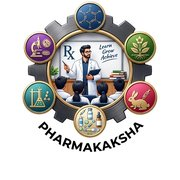

# BP101T · Unit IV — Data Handling with Pandas
**Pharmakaksha · Learn · Grow · Achieve**
*Basics of Python Programming for Pharmaceutical Sciences · B.Pharm Semester I · PCI NEP 2020*

This notebook contains every example and demo from the Unit IV study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP101T%20Basics%20of%20Python%20Programming%20for%20Pharmaceutical%20Sciences%20%28Theory%29/BP101T_Unit4_Data_Handling_with_Pandas.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP101T%20Basics%20of%20Python%20Programming%20for%20Pharmaceutical%20Sciences%20%28Theory%29/BP101T_Unit4_Data_Handling_with_Pandas.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. Cells marked ⌨️ ask you to type something. Type your answer in the box that appears and press Enter.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All dosing and study data in this notebook are for learning Python only. They are not clinical tools.

## Practice datasets
Both datasets are fictional and created for teaching. Run the cell below once to create the files.
- `pk_study.csv`: 8 subjects in a Test vs Reference formulation study, with one missing Cmax and one missing AUC. Cmax is in µg/mL, Tmax in h, AUC in µg·h/mL.
- `adr_reports.csv`: 10 spontaneous ADR reports, with messy drug names and one missing age.

In [ ]:
# Creates the practice dataset file(s) in the notebook folder

pk_study_text = """subject,formulation,weight_kg,cmax,tmax,auc
S01,Test,62,18.4,1.5,112.3
S02,Test,70,16.9,2.0,105.8
S03,Test,58,,1.5,120.1
S04,Test,81,15.2,2.5,98.6
S05,Reference,65,17.8,1.5,110.4
S06,Reference,74,15.9,2.0,101.2
S07,Reference,59,19.1,1.0,118.7
S08,Reference,77,16.3,2.0,
"""
with open("pk_study.csv", "w") as f:
    f.write(pk_study_text)

adr_reports_text = """report_id,drug,age,sex,reaction,serious
R001,Amoxicillin,34,F,Rash,No
R002,amoxicillin ,52,M,Diarrhoea,No
R003,Ibuprofen,67,M,GI bleeding,Yes
R004,Metformin,58,F,Nausea,No
R005,Ibuprofen,,F,Dyspepsia,No
R006,AMOXICILLIN,8,M,Urticaria,No
R007,Atorvastatin,61,M,Myalgia,No
R008,Ibuprofen,72,F,Renal impairment,Yes
R009,Metformin,49,M,Diarrhoea,No
R010,Amoxicillin,27,F,Anaphylaxis,Yes
"""
with open("adr_reports.csv", "w") as f:
    f.write(adr_reports_text)
print("Saved: pk_study.csv, adr_reports.csv")

## 4.1 Introduction to Pandas: Series and DataFrame
Pandas is Python's library for tables, a programmable Excel. Always import it as `pd`.

A **Series** is one labelled column. Every value has an **index** label.

In [ ]:
import pandas as pd

cmax = pd.Series([18.4, 16.9, 15.2], index=["S01", "S02", "S04"], name="cmax")
print(cmax)
print(cmax["S02"])
print(round(cmax.mean(), 2))

A **DataFrame** is a table. Each column is a Series. You can build one from a dictionary of lists:

In [ ]:
df = pd.DataFrame({
    "drug": ["Paracetamol", "Ibuprofen", "Metformin"],
    "dose_mg": [500, 400, 500],
    "half_life_h": [2.5, 2.0, 6.2],
})
df

In [ ]:
print(df["dose_mg"])          # one column -> a Series
print(df.shape)               # (rows, columns)
print(list(df.columns))       # the column names

**Why Pandas?** The mean molecular weight took a loop in Unit III. In Pandas it is one line:

In [ ]:
drugs = pd.DataFrame({"drug": ["Paracetamol", "Ibuprofen", "Aspirin", "Metformin", "Amlodipine", "Atorvastatin"],
                      "mw": [151.16, 206.28, 180.16, 129.16, 408.88, 558.64]})
print(round(drugs["mw"].mean(), 2))

## 4.2 Reading CSV and Excel files
Pandas detects the data types automatically. Empty cells become **NaN**, Pandas' marker for a missing value.

In [ ]:
pk = pd.read_csv("pk_study.csv")
adr = pd.read_csv("adr_reports.csv")
pk

**Useful read_csv options:** load only some columns, or use a column as the row labels.

In [ ]:
display(pd.read_csv("adr_reports.csv", usecols=["drug", "age"]).head(3))
display(pd.read_csv("pk_study.csv", index_col="subject").head(3))

**Saving results.** `index=False` stops Pandas writing the row numbers.

In [ ]:
pk.to_csv("pk_clean.csv", index=False)
print(open("pk_clean.csv").read())

**Excel files** need the `openpyxl` package. It is already in Colab; on learn.pharmakaksha.com, run the next cell once to install it.

In [ ]:
%pip install openpyxl

In [ ]:
adr.to_excel("adr_reports.xlsx", index=False)       # write an Excel file
adr_x = pd.read_excel("adr_reports.xlsx")           # read it back
# pd.read_excel("data.xlsx", sheet_name="ADR")      # choose a sheet by name
adr_x.head(3)

## 4.3 Inspecting a dataset
Look before you analyse.

In [ ]:
pk.head()        # first 5 rows; head(3) gives the first 3

In [ ]:
pk.tail(2)       # last 2 rows

In [ ]:
pk.shape         # (rows, columns): an attribute, so no brackets

`info()` shows each column's type and **non-null count**. Cmax and AUC have 7 of 8, so one value is missing in each.

In [ ]:
pk.info()

`describe()` gives summary statistics for the numeric columns.

In [ ]:
pk.describe().round(2)

In [ ]:
print(pk.dtypes)
print(pk["formulation"].value_counts())
print(pk["formulation"].unique())

## 4.4 Data cleaning and missing values
**Step 1: find the missing values.**

In [ ]:
pk.isnull().sum()

**Step 2: choose a strategy.** Dropping rows:

In [ ]:
print(pk.dropna().shape)                    # drop rows with any NaN: 8 -> 6 rows
print(pk.dropna(subset=["cmax"]).shape)     # drop only if cmax is missing

Filling with the mean (Cmax) and the median (AUC). `copy()` keeps the original `pk` unchanged.

In [ ]:
pk_filled = pk.copy()
pk_filled["cmax"] = pk_filled["cmax"].fillna(pk_filled["cmax"].mean())   # S03 -> 17.09
pk_filled["auc"] = pk_filled["auc"].fillna(pk_filled["auc"].median())    # S08 -> 110.4
pk_filled.round(2)

> **Regulatory note:** in real BE and clinical studies, missing data are **not** simply filled in. The protocol and statistical analysis plan decide. Imputation here is a teaching exercise.

**Step 3: clean text columns.** First count the drug names as they are:

In [ ]:
adr["drug"].value_counts()

The `.str` accessor applies string methods to a whole column:

In [ ]:
adr["drug"] = adr["drug"].str.strip().str.title()
adr["drug"].value_counts()

Before cleaning, Amoxicillin seemed to have 2 reports. After cleaning it is first, with 4. Dirty data changes conclusions.

**Other cleaning tools:**

In [ ]:
pk["cmax_per_kg"] = pk["cmax"] / pk["weight_kg"]             # add a calculated column
display(pk.head(3).round(3))
display(pk.rename(columns={"cmax": "cmax_ug_ml"}).head(2))   # rename a column
display(pk.drop(columns=["cmax_per_kg"]).head(2))            # drop a column
print(adr["age"].astype(float).head(3))                      # change a type
print(len(pd.concat([adr, adr]).drop_duplicates()))          # 20 rows -> 10 after removing duplicates
pk = pk.drop(columns=["cmax_per_kg"])                        # back to the original columns

## 4.5 Filtering and selecting data
**Selecting columns:** one column gives a Series; several columns (double brackets) give a DataFrame.

In [ ]:
print(pk["cmax"].head(3))
pk[["subject", "cmax"]].head(3)

**Filtering rows with a condition** (a boolean mask):

In [ ]:
pk[pk["cmax"] > 17]

**Combining conditions:** `&` (and), `|` (or), `~` (not). Each condition goes in **its own brackets**.

In [ ]:
pk[(pk["formulation"] == "Test") & (pk["tmax"] <= 1.5)]

In [ ]:
adr[adr["serious"] == "Yes"][["drug", "reaction"]]

In [ ]:
adr[adr["drug"].isin(["Ibuprofen", "Metformin"])]

Using `and` instead of `&` raises a **ValueError**. Remove the `#` to see it, then put it back.

In [ ]:
# pk[(pk["formulation"] == "Test") and (pk["tmax"] <= 1.5)]   # ValueError
pk[(pk["formulation"] == "Test") | (pk["tmax"] <= 1.5)].shape

**loc** selects by labels and conditions; **iloc** selects by integer positions ("i" for integer).

In [ ]:
pk.loc[pk["weight_kg"] > 70, ["subject", "cmax"]]

In [ ]:
pk.iloc[0:3, 0:2]

**Sorting:**

In [ ]:
pk.sort_values("cmax", ascending=False).head(3)

## 4.6 Grouping and aggregation
`groupby` follows **split → apply → combine**: split the rows into groups, apply a summary to each, and combine the results.

In [ ]:
pk.groupby("formulation")["cmax"].mean().round(2)

**Several statistics at once.** Missing values are skipped automatically.

In [ ]:
pk.groupby("formulation")[["cmax", "auc"]].agg(["mean", "std"]).round(2)

**Named aggregation on the ADR data** (drug names already cleaned):

In [ ]:
adr.groupby("drug").agg(reports=("report_id", "count"),
                        mean_age=("age", "mean")).round(1)

Ibuprofen's mean age uses 2 of its 3 reports, because one age is missing. `value_counts()` is a shortcut for counting categories:

In [ ]:
adr["sex"].value_counts()

**Interpretation:** the Test and Reference means for Cmax and AUC are close, which is what a bioequivalence study hopes to see. Whether they are *statistically* equivalent (the 90% CI of the ratio within 80–125%) is tested in BP201T Biostatistics.

## Quick check
How many rows does `pk.dropna()` keep, and why? Decide first, then run the cell.

In [ ]:
len(pk.dropna())

## Try it yourself (lab)
Write your code in the empty cells. Solutions are at the end of the notebook.

**1.** Load `adr_reports.csv`, clean the drug names, and find the drug with the most serious reports.

In [ ]:
# your code here

**2.** Fill the missing age with the median age, then find the mean age of male and female reporters.

In [ ]:
# your code here

**3.** Add a column `elderly` that is True when age ≥ 65, and count the elderly reports.

In [ ]:
# your code here

**4.** Save the cleaned ADR table to Excel, then reload it and check its shape.

In [ ]:
# your code here

---
## Solutions

In [ ]:
# 1
adr = pd.read_csv("adr_reports.csv")
adr["drug"] = adr["drug"].str.strip().str.title()
serious = adr[adr["serious"] == "Yes"]["drug"].value_counts()
print(serious)
print("Most serious reports:", serious.idxmax())

In [ ]:
# 2
adr["age"] = adr["age"].fillna(adr["age"].median())
adr.groupby("sex")["age"].mean().round(1)

In [ ]:
# 3
adr["elderly"] = adr["age"] >= 65
print(adr["elderly"].sum(), "elderly reports")

In [ ]:
# 4
adr.to_excel("adr_clean.xlsx", index=False)
print(pd.read_excel("adr_clean.xlsx").shape)

---
**Next:** Unit V — Data Visualization with Matplotlib. Pharmakaksha · Learn · Grow · Achieve